# 0.펭귄분류 + 모델의 성능을 확인하는 기능
- 오전 : 다중분류 + 모델 성능 개선 기능
- 오후 : 모델 조사 기간(탐험단)
- 종속변수 : species
- 독립변수 : species 이외 all



# 1.목표
- 펭귄 데이터를 활용하여 다중분류 실습을 진행해보자
- 데이터 전처리(인코딩)을 적용해보자
- 모델의 일반화 성능(교차검증)을 확인해보자

- 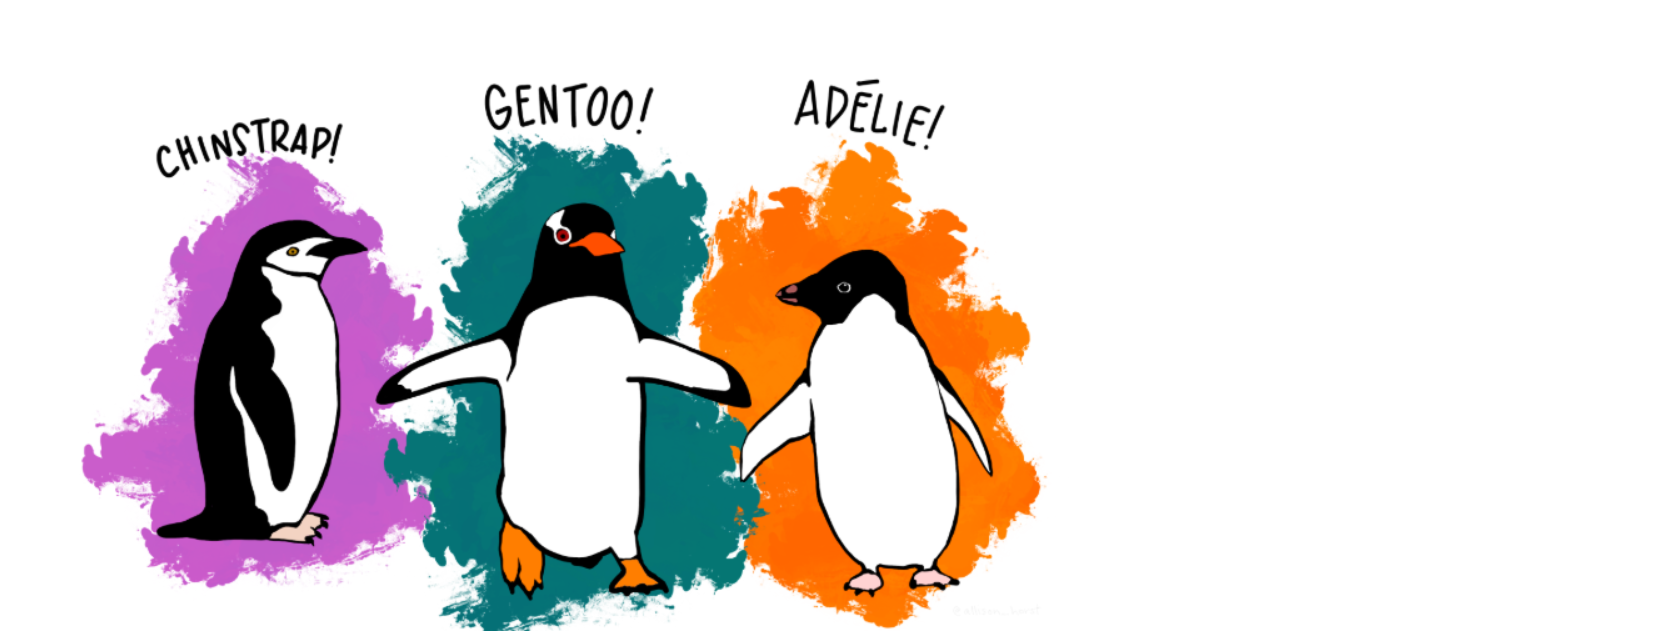

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2.데이터 로딩(수집)
- kaggle 사이트를 통해서 확보된 데이터
- drive 업로드 된 데이터를 불러오려면
  - myDrive 연동
  - 경로 설정(절대경로 => 상대경로)


In [ ]:
# colab 에서 확인할 수 있는 최상단 루트 : C 드라이브
# colab 에서 확인할 수 있는 최상단 루트 : content
# /content/drive/MyDrive/Colab Notebooks/Machine_Learning/data/~~~.csv
# %pwd: 작업환경의 위치 확인
# %pwd
# %cd "/content/drive/MyDrive/Colab Notebooks/Machine_Learning"

/content/drive/MyDrive/Colab Notebooks/Machine_Learning


In [ ]:
# %pwd

'/content/drive/MyDrive/Colab Notebooks/Machine_Learning'

In [2]:

# pd.read_csv()
df = pd.read_csv("./data/penguins_size.csv")

# 위에서 행 5개 출력
df.head()


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [100]:
# species: penguin species (Chinstrap, Adélie, or Gentoo)
# culmen_length_mm : 부리 길이 (mm)
# culmen_depth_mm : 부리 깊이 (mm)
# flipper_length_mm : 날개 길이 (mm)
# body_mass_g : 몸무게 (g)
# island: island name (Dream, Torgersen, or Biscoe) in the Palmer Archipelago (Antarctica)
# sex: penguin sex

# **Culmen(컬멘)**은 새 부리의 윗부분 능선, 즉 부리의 윗쪽 중앙선을 따라 이어지는 선을 말합니다.
# 일반적으로 부리의 길이를 측정할 때 기준이 되는 부분으로, 얼굴에서 부리가 시작되는 지점부터 부리 끝까지의 윗면 선
# **flipper(플립퍼)**라고 불리는 넓적하고 평평한 형태의 팔다리

In [101]:
# 데이터 정보 확인
df.info()

# (344.7)
# species - 답 데이터
# species 제외한 나머지 - 문제 데이터( 답 데이터를 설명해줄 특성 데이터)
# 결측치 여부 - 컬럼마다 2개( 처리방법 고민 필요)
# 데이터 타입 - 특성에 문자열도 포함 -> 머신러닝 이해불가 -> 수치형태 변형 필요

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


- 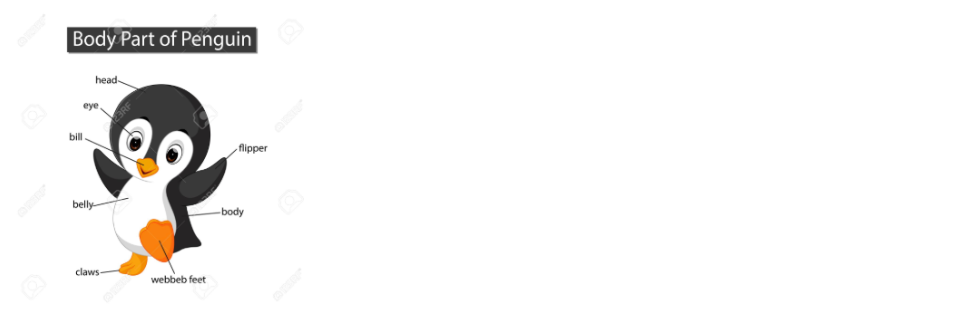

In [ ]:
# 컬럼별로 결측치 개수 확인
# axis = 0(데이터를 확인하는 방향은 아래로 아래로 행방향 == 처리 단위는 열)
# sort_values(ascending=False) : Value 값에 대한 내림차순 정렬
df.isnull().sum().sort_values(ascending=False)

sex                  10
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
species               0
island                0
dtype: int64

In [4]:
# 기술통계량 확인
df.describe(include="all")
# 원래 기본적으로는 수치형 컬럼을 기준으로 기술통계량 확인가능
# 범주형의 다른 컬럼 추가, 에러 해결 => include = "all"

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
count,344,344,342.000000,342.000000,342.000000,342.000000,334
unique,3,3,NaN,NaN,NaN,NaN,3
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,MALE
freq,152,168,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN
std,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN


In [104]:
# 평균값, 50%(중앙값) 차이 큰지 확인
# -- 평균은 이상치의 영향을 많이 받는 수치값
# -- 전체적인 데이터를 설명할 수 있는 대표값인지를 확인
# -- 평균값이 이상치의 영향을 받으면, 다른 대표값으로 데이터 맥락을 확인할 필요가 있음 -> 중앙값

# 사분위수 파악
# max : 6300 몸무게 부분에서 갑자기 큰 값이 들어있지는 않는지?
# -- 몸무게 값때문에 펭귄의 유형을 구분하는데 영향이 있지 않을까?

# 3.데이터 전처리 및 탐색



## 3.1.결측치(NaN) 데이터 다루기: 채우거나 삭제하거나!


In [5]:
# 채우는 방향으로 전처리 진행 -> 정답은 아님! (해보는 것)
from sklearn.impute import SimpleImputer

# SimpleImputer : 데이터 처리하는(채워주는) 기능을 묶고 있는 클래스

# 컬럼별로 각각 결측치 처리
# 평균mean값, 중앙median값, 빈도frequent값(대표값 중 1개)
imputer = SimpleImputer(strategy="most_frequent")
imputer.fit_transform(df)

#df 컬럼에 있는 컬럼명을 사용해준다.
pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# 복사해서 꼬일지 모르니까 copy => 원본은 살려둔다.
df2 = pd.DataFrame(imputer.fit_transform(df), columns=df.columns).copy()


In [6]:
# df2 전체 정보 확인하기
df2.info()

# 각 컬럼별로 빈도값이 제일 높은 값으로 결측치를 채워준 상황!


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   species            344 non-null    object
 1   island             344 non-null    object
 2   culmen_length_mm   344 non-null    object
 3   culmen_depth_mm    344 non-null    object
 4   flipper_length_mm  344 non-null    object
 5   body_mass_g        344 non-null    object
 6   sex                344 non-null    object
dtypes: object(7)
memory usage: 18.9+ KB


In [107]:
#데이터 처리 중에 꼬일 수 있기 때문에 원본을 살리고 온 상황
# df.info()

In [7]:
# 넘파이 배열 특징: 가지고 있는 데이터를 동일한 타입으로 유지하도록 기본적으로 설정
# object : 문자열 포함한 다양한 자료형을 가리킬 때 쓰는 타입(유형, 자료형)
# 원래 수치형태인 컬럼을 다시 되돌릴 필요가 있음(전처리)

#  2   culmen_length_mm   344 non-null    object
#  3   culmen_depth_mm    344 non-null    object
#  4   flipper_length_mm  344 non-null    object
#  5   body_mass_g        344 non-null    object

# 수치형으로 변환할 대상 컬럼 리스트
cols_to_convert = list(df2.columns[2:6])
cols_to_convert

# 문자열을 숫자로 변환(변환 불가 값은 NaN 처리)
df2[cols_to_convert] = df2[cols_to_convert].apply(pd.to_numeric, errors="coerce")
df2.info()



#df.astype()으로 할 경우 현재 데이터에는 적용이 불가하여 위 코드로 진행함

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   344 non-null    float64
 3   culmen_depth_mm    344 non-null    float64
 4   flipper_length_mm  344 non-null    float64
 5   body_mass_g        344 non-null    float64
 6   sex                344 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


c:\Python312\Lib\site-packages\seaborn\axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


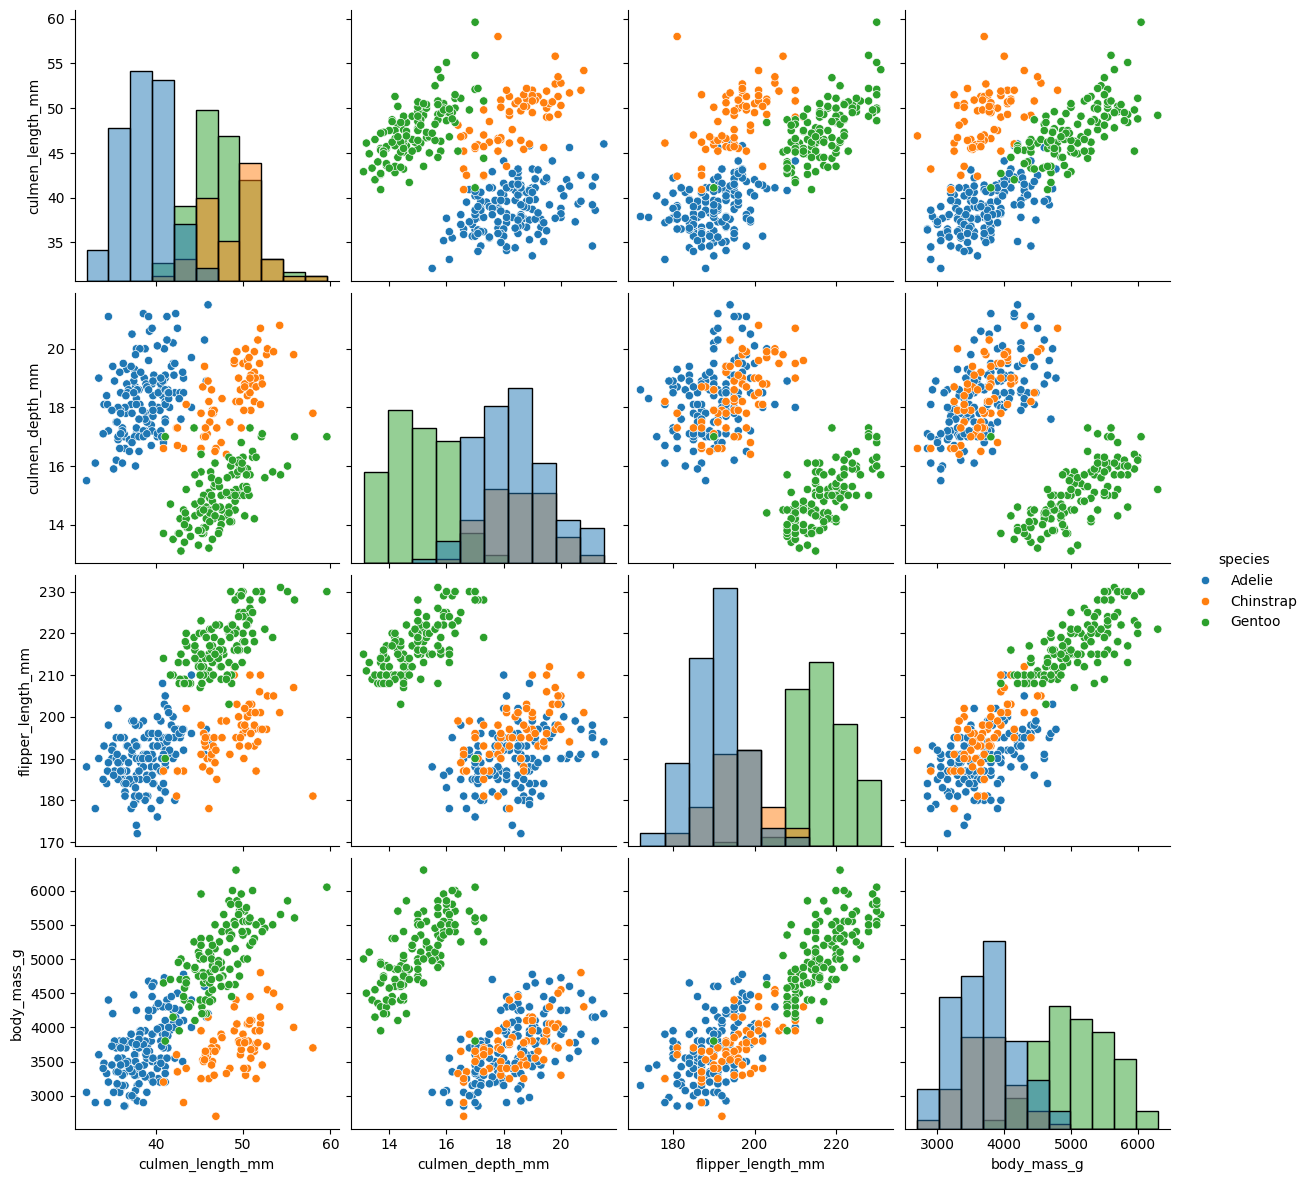

In [8]:
# 위에서 처리한 수치형 데이터를 시각화 해보자
# 각 컬럼(특성)과의 관계성을 파악해보자!

# DF로 만들어서
# sns.pairplot(df2[cols_to_convert], hue="species")
sns.pairplot(df2[["species", "culmen_length_mm", "culmen_depth_mm","flipper_length_mm", "body_mass_g"]],
             hue="species",
             diag_kind="hist",
             size = 3)

## 3.2.수치형 컬럼 데이터 간의 관계 확인 방법(2)

In [9]:
# 분산(variance), 공분산(Covariance) 행렬을 보여주는 기능
print("- 분산:")
df2.cov(numeric_only=True)

# 계산의 결과가 어떻게 나왔는지 공식이 중요하지 않음
# 해석 능력이 필요!
# 자기 자신과의 공분산 = 분산(산포 정도)
# 서로 다른 변수(컬럼) 간의 공분산 해석
# -- 양의 값: 서로의 값이 함께 증가하는 경향이 있음을 의미 (비례관계)
# -- 음의 값: 하나가 증가할수록 다른 하나는 감소하는 경향(반비례관계)
# --> 비례, 반비례 모두 관계성이 있음

# 공분산으로 계산했을 때, 각 컬럼의 수치의 단위가 일정하지 않아서
# 급격하게 크거나 급격하게 작거나 공분산 값이 출력됨.
# 주의할 점은 절대값이 클수록 변수 간 상관관계가 강함을 의미하지만,
# 단위에 따라 값이 커질 수 있어 직접 비교하는 것이 어려운 편
# 모든 특성값을 비교한다고 했을 때, 정확한 상관관계가 알고 싶다면 corr(cor-relation of coefficient) 상관관계를 확인해보는 것이 좋음!
# 상관관계 범위: -1~1 수치를 설명함

- 분산:


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,29.679415,-2.516984,50.260588,2596.971151
culmen_depth_mm,-2.516984,3.877201,-16.108849,-742.660180
flipper_length_mm,50.260588,-16.108849,197.269501,9792.552037
body_mass_g,2596.971151,-742.660180,9792.552037,640316.716388


In [10]:
print("-상관관계 : ")
df2.corr(numeric_only=True)

# -1, 1에 가까울 수록 상관관계가 강함
# 0에 가까울수록 비교적 상관관계가 약함을 뜻함
# culmen_length_mm : flipper_length_mm(0.6568)과 상관관계가 비교적 높은 편
# culmen_depth_mm: flipper_length_mm(-0.582472) 상관관계가 비교적 높은 편
# culmen_depth_mm는 전체적으로 음의 상관관계로 보여지는 편

# flipper_length_mm: body_mass_g(0.871302) 상관관계가 비교적 높은 편
# => 관계가 가장 뚜렷함. 날개가 길수록 몸무게도 무겁다.

# **공분산 행렬보다 훨씬 직관적이고 비교하기 용이**
# 상관관계를 확인하면서 모델이 학습할 때, 종의 유형을 구분하는 규칙에 도움을 줄만한 특성이 있는지, 특성의 조합이 있는지 확인했음.

-상관관계 : 


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,1.000000,-0.234635,0.656856,0.595720
culmen_depth_mm,-0.234635,1.000000,-0.582472,-0.471339
flipper_length_mm,0.656856,-0.582472,1.000000,0.871302
body_mass_g,0.595720,-0.471339,0.871302,1.000000


3. 통계학
	1. E(R<sub>i</sub>) = Expected Rate of Return 기대수익률 $$E(R_{i})=\sum P_{i}R_{i}$$
	2. σ<sub>i</sub><sup>2</sup> = Var(R<sub>i</sub>) Variance 분산 Devi<sub>i</sub><sup>2</sup>P<sub>i</sub>$$Var(R_{i})=σ_{i}^2=\sum[R_{i}-E(R_{i})]^2P_{i}=E(R_{i}^2)-[E(R_{i})]^2$$
	3. σ<sub>i</sub> = Standard Deviation 표준편차 |Devi|$$σ_{i}=\sqrt{ Var(R_{i}) }$$
	4. σ<sub>12</sub> = Cov(R<sub>i</sub>, R<sub>j</sub>) Covariance 공분산 Devi<sub>i</sub> Devi<sub>j</sub>$$Cov(R_{i} ,R_{j}) = σ_{ij}=\sum[R_{i}-E(R_{i})][R_{j}-E(R_{j})]P^A=E[Devi]$$
	5. ρ<sub>12</sub> =  Co-efficient of Cor-relation = 상관계수$$ρ_{ij}= \frac{Cov({R_{i}R_{j}})}{\sqrt{ Var(R_{i}}) *\sqrt{ Var(R_{j})}}=\frac{σ_{ij}}{σ_{i}σ_{j}} $$

## 3.3.문자열 데이터 전처리 및 데이터 탐색
- 문자열 형태 데이터 다뤄보기
- 머신러닝 모델은 특성(문제) 데이터가 문자열이면 계산을 못하기 때문에 수치형으로 변형이 필요
- 문자=>숫자 (encoding, 인코딩)
  - Label인코딩(라벨 인코딩)
  - One-hot인코딩(원핫 인코딩)

In [11]:
# 예시 데이터를 활용해서 맛보기
from sklearn.preprocessing import LabelEncoder

# 예시 데이터
# 문자열 형태
labels = ["dog", "cat", "dog", "fish"]

# 도구 객체 생성
le = LabelEncoder()

# -1. 라벨링 인코딩 수행: 1차원 배열만 다룰 수 있음
encoded = le.fit_transform(labels)
# fit() : 데이터를 인식하는 단계
# transform(): 다양한 문자열 확인했으니 어떤 문자열은 특정 숫자로 매칭
# parameter labels 넣어주기
# encoded변수에 넣어주기
# 알파벳 순서대로 0번부터 숫자 매칭(맵핑)
print("클래스 목록: ", labels)
print("인코딩 결과:", encoded)

# 인코딩 결과에서 원래 문자열 값으로 복원 (디코딩)
le.inverse_transform(encoded)
# 결과출력
print("디코딩 결과: ", le.inverse_transform(encoded) )

클래스 목록:  ['dog', 'cat', 'dog', 'fish']
인코딩 결과: [1 0 1 2]
디코딩 결과:  ['dog' 'cat' 'dog' 'fish']


## 3.4.🎈¿언제 라벨 인코더 대신 원핫 인코딩(Range to Vector)을 사용할까?
- LabelEncoder는 순서 없는 범주형 변수에도 정수를 부여하기 때문에 숫자의 크기 비교가 생길 수 있음.
- 크고 작음의 의미가 있는 데이터에서는 사용해도 좋지만, 반대로 아닐 경우에는 사용했을 때 의미를 혼동시키는 경우가 발생할 수 있다.
- 머신러닝 알고리즘에서는 대체적으로 원핫 인코딩을 사용함

In [12]:
# 원핫 인코딩 함수 맛보기
# pd.get_dummies(대상)
print(labels)
pd.get_dummies(labels)

# False 0
# True 1
# 가지고 있는 데이터의 범주만큼 컬럼을 만들고, 해당 컬럼 이름에 매칭되는 데이터가 있으면1 (True), 아니면0 (False) 변환

['dog', 'cat', 'dog', 'fish']


,cat,dog,fish
0,False,True,False
1,True,False,False
2,False,True,False
3,False,False,True


In [13]:
# df2 본 데이터에서 문자열 형태 데이터 확인
#df2.info()

# cat_features = df2.dtypes

df2.dtypes == "object" # or 대문자 "O"

(df2.dtypes == "object").values

df2.columns[(df2.dtypes == "object").values]


cat_features = df2.columns[(df2.dtypes == "object").values]
cat_features


Index(['species', 'island', 'sex'], dtype='object')

<Axes: xlabel='species'>

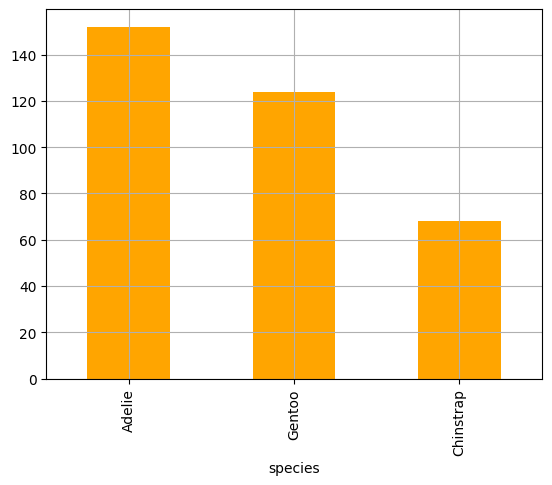

In [14]:
# 각 컬럼별로 막대그래프 시각화
# sns, plt 도구
# pd 시각화 도구 연결


df2[cat_features[0]].value_counts().plot(kind="bar", grid=True, color = "orange")

<Axes: ylabel='island'>

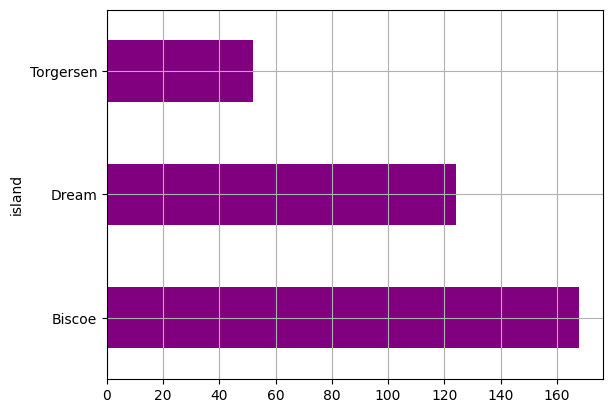

In [15]:
df2[cat_features[1]].value_counts().plot(kind="barh", grid=True, color = "purple")

<Axes: ylabel='sex'>

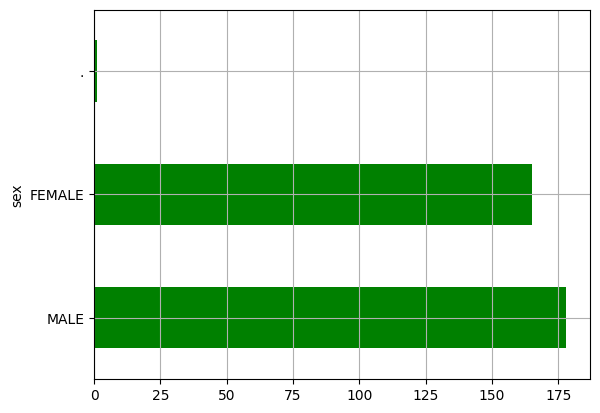

In [16]:
# 성별의 .이 무엇인지 이상치(outlier) 처리를 어떻게 해야하나?
df2[cat_features[2]].value_counts().plot(kind="barh", grid=True, color = "green")

In [17]:
# sex에 있는 . 데이터를 처리해보자
# 성별컬럼에 .이 있는 행 데이터 출력해보기(접근해보기)
df2[df2["sex"] =="."]

# 1개 행 삭제 방향 정리 => 정답X
df2.drop(336, inplace = True)
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 343 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            343 non-null    object 
 1   island             343 non-null    object 
 2   culmen_length_mm   343 non-null    float64
 3   culmen_depth_mm    343 non-null    float64
 4   flipper_length_mm  343 non-null    float64
 5   body_mass_g        343 non-null    float64
 6   sex                343 non-null    object 
dtypes: float64(4), object(3)
memory usage: 21.4+ KB


<Axes: ylabel='sex'>

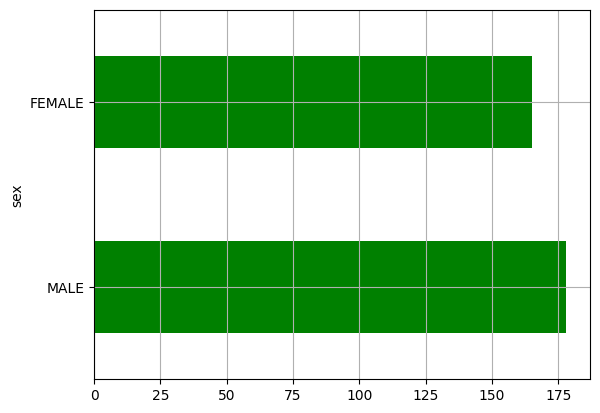

In [18]:
df2[cat_features[2]].value_counts().plot(kind="barh", grid=True, color = "green")

In [19]:
# 문자형 => 수치형
#cat_features[1:3]
# DataFrame로
# df2[cat_features[1:3]]

#encoding
cat_df = pd.get_dummies(df2[cat_features[1:3]])

#df2 본 데이터에 해당 변경 내용을 추가, 기존 문자열 컬럼은 제거
df2 = pd.concat([df2, cat_df], axis = 1)
df2.drop(cat_features[1:3], axis=1, inplace=True)
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 343 entries, 0 to 343
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            343 non-null    object 
 1   culmen_length_mm   343 non-null    float64
 2   culmen_depth_mm    343 non-null    float64
 3   flipper_length_mm  343 non-null    float64
 4   body_mass_g        343 non-null    float64
 5   island_Biscoe      343 non-null    bool   
 6   island_Dream       343 non-null    bool   
 7   island_Torgersen   343 non-null    bool   
 8   sex_FEMALE         343 non-null    bool   
 9   sex_MALE           343 non-null    bool   
dtypes: bool(5), float64(4), object(1)
memory usage: 17.8+ KB


# 4.데이터 분리
- 문제, 답 분리
- 학습용, 테스트용 분리 : train_test_split
  - 1) 랜덤 섞기
  - 2) 비율에 따라 분리
  - 7:3
  - random_state = 7 (랜덤하게 섞이는 규칙 고정해보기)
  - X_train, X_test, y_train, t_test
  - 독립변수 (이외 all ), 종속변수 (species)
- 크기확인

In [20]:
X = df2.iloc[:, 1: ]  # 문제
y = df2.iloc[:, 0]    # 답
print(X.shape)
print(y.shape)

(343, 9)
(343,)


In [21]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 343 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   343 non-null    float64
 1   culmen_depth_mm    343 non-null    float64
 2   flipper_length_mm  343 non-null    float64
 3   body_mass_g        343 non-null    float64
 4   island_Biscoe      343 non-null    bool   
 5   island_Dream       343 non-null    bool   
 6   island_Torgersen   343 non-null    bool   
 7   sex_FEMALE         343 non-null    bool   
 8   sex_MALE           343 non-null    bool   
dtypes: bool(5), float64(4)
memory usage: 15.1 KB


In [22]:
from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(문제, 답, 크기, 고정값, stratify = y)  =>
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7, stratify = y)
# stratify=y 학습을 잘하기 위해서 답 데이터의 다양성이 보장되어야함(균형이 맞아야함)
# y안에 있는 클래스의 비율을 확인해서 데이터를 균등하게 train, test로 분리하는 기능

print("학습용:", X_train.shape, y_train.shape)
print("테스트용:", X_test.shape, y_test.shape)

학습용: (240, 9) (240,)
테스트용: (103, 9) (103,)


# 5.모델링
- 모델 객체 생성
- 학습
- 예측
- 평가(예측과 실제를 비교)

In [23]:
from sklearn.tree import DecisionTreeClassifier # 펭귄 종류 3개를 분류 문제
from sklearn.ensemble import RandomForestClassifier # 분류 문제 해결하는 모델

In [24]:
# 모델 객체 생성해보기!
# 세부 매개변수는 기본값
tree_clf = DecisionTreeClassifier() # random_state 값이 존재

# tree_model
rf_clf = RandomForestClassifier(random_state= 0) # 트리 여러개(100개 이상)를 결합한 모델, random_state 값이 존재 4

In [25]:
# 모델 학습
# 모델명.fit(문제, 답)
tree_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
# 모델 예측
# 테스트 문제
tree_pre = tree_clf.predict(X_test)
rf_pre = rf_clf.predict(X_test)



In [27]:
# 모델마다 알고리즘(규칙)을 생성하는 방식이 다르기 대문에
# 예측과 예측 성능이 다름
print("tree_pre", tree_pre[60:80])
print("rf_pre", rf_pre[60:80])
# 해당 범위의 예측 결과는 큰 차이가 없음, 완전 동일 => 다른 범위는 어떨까?

tree_pre ['Gentoo' 'Chinstrap' 'Adelie' 'Chinstrap' 'Gentoo' 'Chinstrap' 'Adelie'
 'Adelie' 'Chinstrap' 'Chinstrap' 'Adelie' 'Gentoo' 'Adelie' 'Chinstrap'
 'Adelie' 'Adelie' 'Gentoo' 'Adelie' 'Gentoo' 'Chinstrap']
rf_pre ['Gentoo' 'Chinstrap' 'Adelie' 'Chinstrap' 'Gentoo' 'Chinstrap' 'Adelie'
 'Adelie' 'Chinstrap' 'Chinstrap' 'Adelie' 'Gentoo' 'Adelie' 'Chinstrap'
 'Gentoo' 'Adelie' 'Gentoo' 'Adelie' 'Gentoo' 'Chinstrap']


In [28]:
# 모델 성능 - 정확도
from sklearn.metrics import accuracy_score
# accuracy_score(실제, 예측)
print(f'tree_acc: {accuracy_score(y_test, tree_pre):.3f}')
print(f'rf_acc: {accuracy_score(y_test,rf_pre):.3f}')

tree_acc: 0.942
rf_acc: 0.990



# 6.일반화 평가 및 성능 향상을 위한 노력
- 일반 성능 평가: 교차 검증 (cross validation)

In [29]:
# 여러번 검증한다!!
from sklearn.model_selection import cross_val_score # 교차검증 도구
from sklearn.model_selection import GridSearchCV # 그리드 서치 도구
from sklearn.model_selection import cross_val_score, GridSearchCV # => 한번에 진행한다.

In [30]:
# tree (decision tree)
print("tree cv:\n", cross_val_score(tree_clf, X_train, y_train, cv=5 ))
print(cross_val_score(tree_clf, X_train, y_train, cv=5 ).mean())
# rf (random forest)
print("rf cv:\n", cross_val_score(rf_clf, X_train, y_train, cv=5 ))
print(cross_val_score(rf_clf, X_train, y_train, cv=5 ).mean())

# tree 검증 정확도 평균의 경우 90% 이상의 성능을 보이고, 4개 90% 이상, 1개는 80% 대를 보여주어 중간정도의 변동성이 있는 것으로 확인
# rf 검증 정확도 평균의 경우 95% 이상의 성능을 보이고, 전체적으로 안정적이고 높은 성능을 보인다.
# tree보다는 rf 모델의 일반화가 더 성립이 된 것을 확인


# 과대적합일 수 있는 경우가 존재함, 미묘하게라도 과대적합을 해소해줄 필요가 있음 -> 대체적으로 높은 편이긴 하지만...
# 2번째 검증 데이터(모델이 설정한, 쪼개놓은 검증 데이터) 자체적으로 에측하기 어려운 데이터였을 수도 있음!


tree cv:
 [1.         0.875      0.97916667 0.97916667 0.9375    ]
0.9375
rf cv:
 [1.         0.91666667 1.         0.97916667 0.97916667]
0.975


- 성능 향상 시키기 : 그리드서치(GridSearchCV)
그리드 서치는 하이퍼파라미터 후보들을 격자(grid) 형식으로 조합하여, 각 조합에 대해 교차검증을 수행하고 최적의 파라미터를 찾는 방법(도구)
  - 여러 파라피터 조합을 모두 테스트
  - 내부적으로 교차검증(cv=[3,5]) 를 수행
  - 최적 모델(best_estimator_)과 최적 성능(best_score_)제공
  - 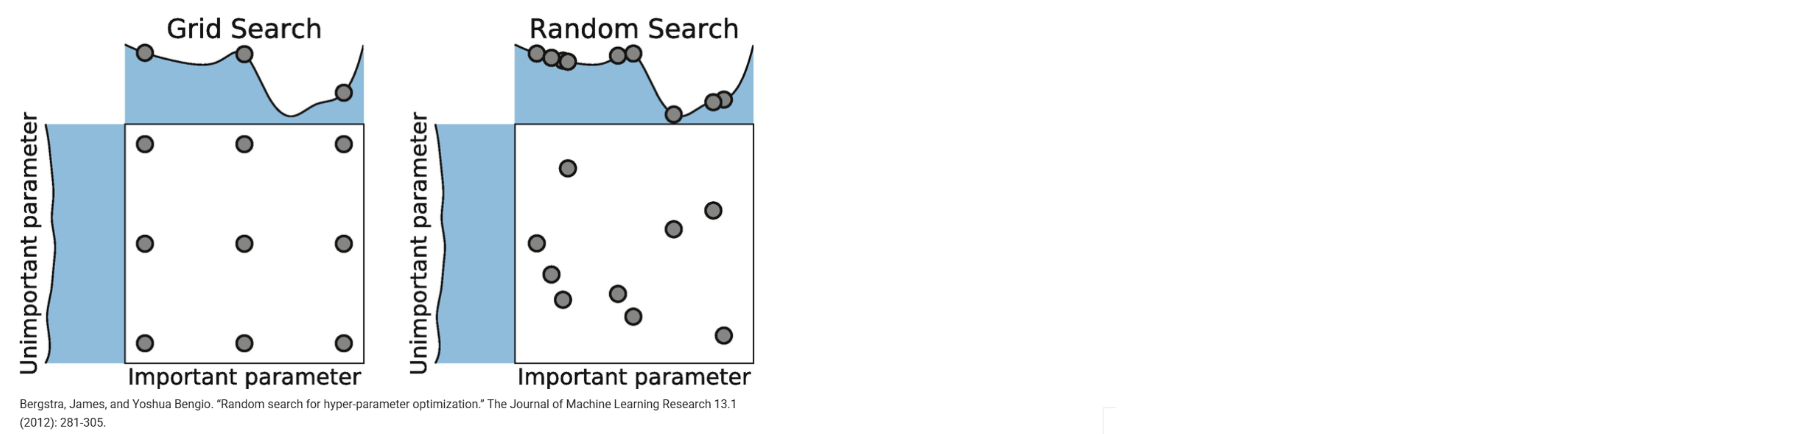

In [31]:
## Grid Search 사용방법
## 하이퍼 파라미터 후보 설정
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [None, 3, 5, 7],   #
    "min_samples_split": [2, 4]     # 모델의 복잡도(규칙)를 제어하는 역할
}

# 그리드 서치 객체 정의
grid_search = GridSearchCV(
    estimator = RandomForestClassifier(random_state = 0),
    param_grid = param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs= -1, # 사용할 수 있는 pc의 계산 능력 최대로 사용
    verbose=1 # 그리드 서치 수행 현황을 출력해라
)

# 그리드 서치 적용(학습)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,RandomForestC...andom_state=0)
,param_grid,"{'max_depth': [None, 3, ...], 'min_samples_split': [2, 4], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [32]:
# 최적의 하이퍼 파라미터 및 성능 출력
print("최적 하이퍼 파라미터: ", grid_search.best_params_)
print("최적의 성능: ", grid_search.best_score_)
# 나름대로 후보들 안에서 검증을 진행한 후
# 과대적합도 제어되면서 최적일때의 성능을 확인한 것

최적 하이퍼 파라미터:  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
최적의 성능:  0.9791666666666666


In [33]:
# 최적의 모델 정리!!
# 테스트 적용, 평가, 예측 활용
best_rf = grid_search.best_estimator_
best_rf

y_pred = best_rf.predict(X_test)
print(y_pred)

['Adelie' 'Gentoo' 'Adelie' 'Gentoo' 'Adelie' 'Adelie' 'Adelie'
 'Chinstrap' 'Adelie' 'Adelie' 'Adelie' 'Chinstrap' 'Gentoo' 'Adelie'
 'Adelie' 'Gentoo' 'Gentoo' 'Chinstrap' 'Adelie' 'Gentoo' 'Gentoo'
 'Adelie' 'Gentoo' 'Gentoo' 'Chinstrap' 'Gentoo' 'Adelie' 'Adelie'
 'Adelie' 'Gentoo' 'Chinstrap' 'Adelie' 'Chinstrap' 'Gentoo' 'Gentoo'
 'Gentoo' 'Gentoo' 'Adelie' 'Chinstrap' 'Gentoo' 'Adelie' 'Adelie'
 'Adelie' 'Adelie' 'Adelie' 'Adelie' 'Gentoo' 'Gentoo' 'Adelie' 'Gentoo'
 'Gentoo' 'Gentoo' 'Adelie' 'Gentoo' 'Adelie' 'Adelie' 'Adelie' 'Adelie'
 'Gentoo' 'Adelie' 'Gentoo' 'Chinstrap' 'Adelie' 'Chinstrap' 'Gentoo'
 'Chinstrap' 'Adelie' 'Adelie' 'Chinstrap' 'Chinstrap' 'Adelie' 'Gentoo'
 'Adelie' 'Chinstrap' 'Gentoo' 'Adelie' 'Gentoo' 'Adelie' 'Gentoo'
 'Chinstrap' 'Gentoo' 'Gentoo' 'Adelie' 'Gentoo' 'Chinstrap' 'Adelie'
 'Adelie' 'Adelie' 'Gentoo' 'Adelie' 'Adelie' 'Chinstrap' 'Adelie'
 'Chinstrap' 'Gentoo' 'Chinstrap' 'Gentoo' 'Chinstrap' 'Gentoo'
 'Chinstrap' 'Adelie' 'Gentoo' 'Chinst

In [34]:
# print(f"교차검증 정확도:{cross_val_score(모델명, 문제, 답, 검증횟수)}")
print(f"교차검증 정확도:{cross_val_score(best_rf, X_train, y_train, cv=5)}")
print(f"교차검증 정확도 평균:{cross_val_score(best_rf, X_train, y_train, cv=5).mean()}")

교차검증 정확도:[1.         0.91666667 1.         0.97916667 1.        ]
교차검증 정확도 평균:0.9791666666666666


In [35]:
# 그리드 서치 적용한 rf, 이전 rf 성능 차이가 많이 날까?
# -- 그리더 서치를 적용하기 전에도 나름 성능이 좋은 상황
# -- 적용한 이후 전체적으로 평균값이 향상, 일반화 성능 개선이 있었음
# -- 2번째 데이터를 더 잘 예측할 수 있는 모델은 없을까?

# print(f"교차검증 정확도:{cross_val_score(모델명, 문제, 답, 검증횟수)}")
print(f"교차검증 정확도:{cross_val_score(rf_clf, X_train, y_train, cv=5)}")
print(f"교차검증 정확도 평균:{cross_val_score(rf_clf, X_train, y_train, cv=5).mean()}")

교차검증 정확도:[1.         0.91666667 1.         0.97916667 0.97916667]
교차검증 정확도 평균:0.975
